In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load fitted Hill model sampling results
idata = az.from_netcdf("../data/hill_mmm_inference_data.nc")
print("Hill MMM inference data loaded successfully!")

Hill MMM inference data loaded successfully!


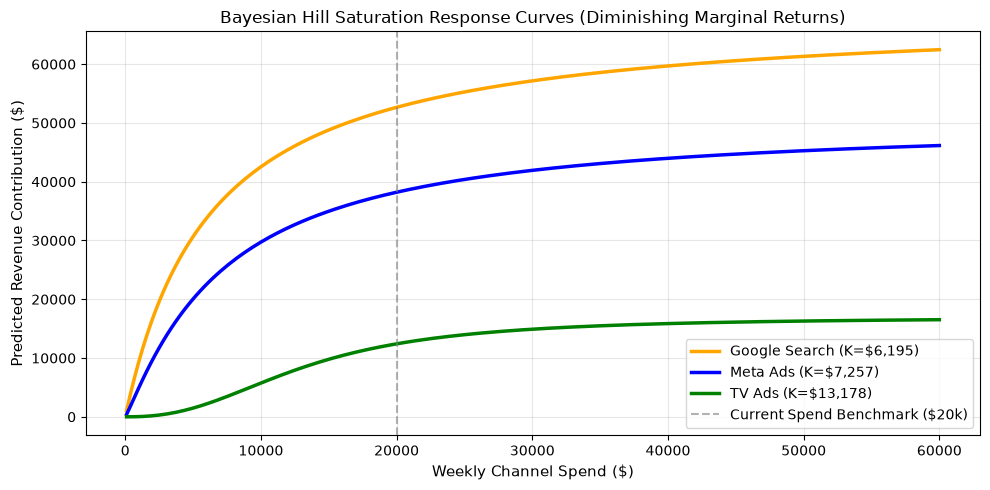

In [2]:
# Function to evaluate Hill curve given posterior parameter draws
def compute_hill_curve(spend_range, beta, K, S):
    return beta * (spend_range**S / (K**S + spend_range**S))

spend_grid = np.linspace(0.01, 6.0, 200) # $0 to $60,000 spend range

# Extract posterior parameter means
post = idata.posterior
b_meta, K_meta, S_meta = post["beta_meta"].mean().item(), post["K_meta"].mean().item(), post["S_meta"].mean().item()
b_goog, K_goog, S_goog = post["beta_google"].mean().item(), post["K_google"].mean().item(), post["S_google"].mean().item()
b_tv, K_tv, S_tv = post["beta_tv"].mean().item(), post["K_tv"].mean().item(), post["S_tv"].mean().item()

# Compute curves
resp_meta = compute_hill_curve(spend_grid, b_meta, K_meta, S_meta) * 10000.0
resp_goog = compute_hill_curve(spend_grid, b_goog, K_goog, S_goog) * 10000.0
resp_tv = compute_hill_curve(spend_grid, b_tv, K_tv, S_tv) * 10000.0
spend_dollars = spend_grid * 10000.0

# Plot S-Curves
plt.figure(figsize=(10, 5))
plt.plot(spend_dollars, resp_goog, label=f"Google Search (K=${K_goog*10000:,.0f})", color="orange", linewidth=2.5)
plt.plot(spend_dollars, resp_meta, label=f"Meta Ads (K=${K_meta*10000:,.0f})", color="blue", linewidth=2.5)
plt.plot(spend_dollars, resp_tv, label=f"TV Ads (K=${K_tv*10000:,.0f})", color="green", linewidth=2.5)

plt.title("Bayesian Hill Saturation Response Curves (Diminishing Marginal Returns)", fontsize=12)
plt.xlabel("Weekly Channel Spend ($)", fontsize=11)
plt.ylabel("Predicted Revenue Contribution ($)", fontsize=11)
plt.axvline(x=20000, color="gray", linestyle="--", alpha=0.6, label="Current Spend Benchmark ($20k)")
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()